In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
folder = "xitermpairs/1049_0_64_1024_0"

In [5]:
rounds = list(range(1, 65))
dfs = []
for round in tqdm(rounds):
    dfs.append(pd.read_csv(f"{folder}/{round}.csv"))
df_full = pd.concat(dfs, ignore_index=True)

100%|██████████| 64/64 [00:15<00:00,  4.14it/s] 


In [6]:
print(len(df_full))

16777216


### Approach 1: In Full Rounds (Batch Stream)

In [7]:
num_samples_by_rounds = []
cov_estimates_by_round = []
for round in tqdm(rounds):
    df = pd.concat(dfs[:round])
    num_samples_by_rounds.append(len(df))

    if len(df) > 1:
        cov_estimates_by_round.append(np.cov(df[["xi_x", "xi_y"]].values.T)[0, 1])
        if len(df) > 10**5:
            break
    else:
        cov_estimates_by_round.append(0)

 27%|██▋       | 17/64 [00:00<00:00, 323.94it/s]


### Approach 2: Sample by Sample (Sample Stream) - Coincides with Batches on Certain Anchors

In [8]:
cov_estimates_by_sample = []
for n_samples in tqdm(range(1, 10**5 + 1, 10)):
    df = df_full.iloc[:n_samples]
    if len(df) > 1:
        cov_estimates_by_sample.append(np.cov(df[["xi_x", "xi_y"]].values.T)[0, 1])
    else:
        cov_estimates_by_sample.append(0)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:14<00:00, 709.40it/s]


### Approach 2b: Sample by Sample in Oracle Stream

In [9]:
cov_estimates_by_sample_shuffled = []
df_full_shuffled = df_full.sample(n=len(df_full), replace=False)
for n_samples in tqdm(range(1, 10**5 + 1, 10)):
    df = df_full_shuffled.iloc[:n_samples]
    if len(df) > 1:
        cov_estimates_by_sample_shuffled.append(np.cov(df[["xi_x", "xi_y"]].values.T)[0, 1])
    else:
        cov_estimates_by_sample_shuffled.append(0)

100%|██████████| 10000/10000 [00:13<00:00, 762.19it/s]


### Approach 3: Sample by Group-Sample (Sample Stream with Shuffling Inside Groups)

In [10]:
schedule_for_shuffled_stream_groups = []
cov_estimates_by_shuffled_stream_groups = []

def pop_random_rows(df, n):
    random_indices = np.random.choice(df.index, size=n, replace=False)
    popped = df.loc[random_indices].copy()
    df.drop(index=random_indices, inplace=True)
    df.reset_index(drop=True, inplace=True)
    return popped

df = None
round = 1
while df is None or len(df) < 10**5:

    new_df = dfs[round - 1].copy()
    while len(new_df) > 1:
        popped = pop_random_rows(new_df, min(len(new_df), 10))
        df = popped if df is None else pd.concat([df, popped])
        schedule_for_shuffled_stream_groups.append(len(df))

        if len(df) > 1:
            cov_estimates_by_shuffled_stream_groups.append(np.cov(df[["xi_x", "xi_y"]].values.T)[0, 1])
        else:
            cov_estimates_by_shuffled_stream_groups.append(0)
    round += 1

### Approach 4: (Pseudo-)IID Samples with Repplacement (Sample with Replacement)

In [11]:
num_samples_by_rounds_iid_replacement = []
cov_estimates_by_sampling_with_replacement = []
for n_samples in tqdm(range(1, 10**5 + 1, 10)):
    df = pd.concat(dfs[:round])
    num_samples_by_rounds_iid_replacement.append(len(df))
    if len(df) > 1:
        cov_estimates_by_sampling_with_replacement.append(np.cov(df[["xi_x", "xi_y"]].values.T)[0, 1])
    else:
        cov_estimates_by_sampling_with_replacement.append(0)

100%|██████████| 10000/10000 [01:18<00:00, 127.58it/s]


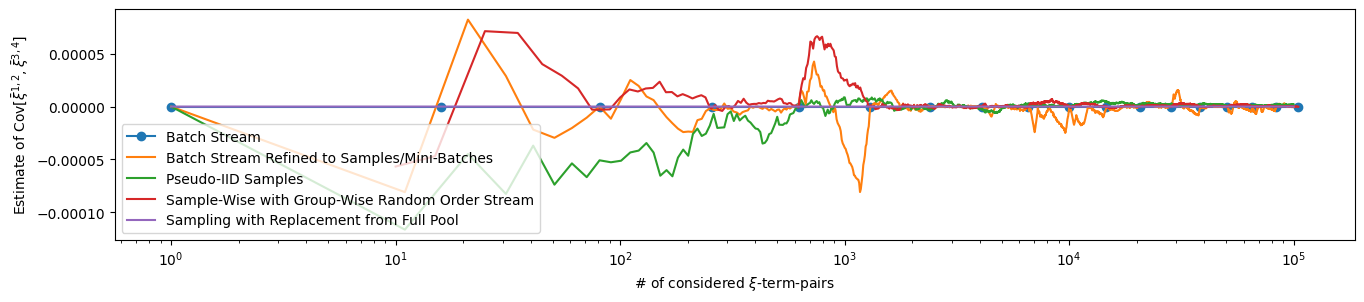

In [12]:
fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(num_samples_by_rounds, cov_estimates_by_round, marker="o", label="Batch Stream")
ax.plot(range(1, 10 * len(cov_estimates_by_sample) + 1, 10), cov_estimates_by_sample, label="Batch Stream Refined to Samples/Mini-Batches")
ax.plot(range(1, 10 * len(cov_estimates_by_sample_shuffled) + 1, 10), cov_estimates_by_sample_shuffled, label="Pseudo-IID Samples")
ax.plot(schedule_for_shuffled_stream_groups, cov_estimates_by_shuffled_stream_groups, label="Sample-Wise with Group-Wise Random Order Stream")
ax.plot(range(1, 10 * len(cov_estimates_by_sampling_with_replacement) + 1, 10), cov_estimates_by_sampling_with_replacement, label="Sampling with Replacement from Full Pool")
ax.set_xlabel(r"# of considered $\xi$-term-pairs")
ax.set_ylabel(r"Estimate of Cov[$\bar{\xi}^{1,2}, \bar{\xi}^{3,4}$]")
ax.set_xscale("log")
ax.legend()
plt.show()